<a href="https://colab.research.google.com/github/specM7/DSGP_Group_33_Brain_Tumor_Predictor/blob/glioblastoma-Vidu-2425444/workingCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import zipfile

zip_path = "/content/drive/MyDrive/archive.zip"
extract_path = "/content/extracted"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done extracting!")

Done extracting!


In [3]:
import os
import shutil
import random

# Configuration
source_dir = "/content/extracted/archive/Training"
target_dir = "/content/binary_dataset/Training"

# Folders to combine into "no_tumor"
other_classes = ["meningioma", "notumor", "pituitary"]
positive_class = "glioma"

# 1. Create target directories
os.makedirs(os.path.join(target_dir, "glioma"), exist_ok=True)
os.makedirs(os.path.join(target_dir, "no_tumor"), exist_ok=True)

# 2. Get the target count from the Glioma folder to ensure balance
glioma_images = os.listdir(os.path.join(source_dir, positive_class))
target_count = len(glioma_images)
images_per_other = target_count // len(other_classes)

print(f"Target count for balance: {target_count}")
print(f"Taking ~{images_per_other} images from each of the other 3 classes.")

# 3. Copy Glioma (all of them)
for img in glioma_images:
    shutil.copy(os.path.join(source_dir, positive_class, img),
                os.path.join(target_dir, "glioma", img))

# 4. Copy a balanced mix for "no_tumor"
for cls in other_classes:
    all_imgs = os.listdir(os.path.join(source_dir, cls))
    selected_imgs = random.sample(all_imgs, min(images_per_other, len(all_imgs)))

    for img in selected_imgs:
        # Prefix the filename with the class name to avoid duplicates
        new_name = f"{cls}_{img}"
        shutil.copy(os.path.join(source_dir, cls, img),
                    os.path.join(target_dir, "no_tumor", new_name))

print("✅ Balanced binary dataset created at:", target_dir)

Target count for balance: 1400
Taking ~466 images from each of the other 3 classes.
✅ Balanced binary dataset created at: /content/binary_dataset/Training


In [4]:
import os
import shutil
import random

# Configuration
source_dir = "/content/extracted/archive/Testing"
target_dir = "/content/binary_dataset/Testing"

# Folders to combine into "no_tumor"
other_classes = ["meningioma", "notumor", "pituitary"]
positive_class = "glioma"

# 1. Create target directories
os.makedirs(os.path.join(target_dir, "glioma"), exist_ok=True)
os.makedirs(os.path.join(target_dir, "no_tumor"), exist_ok=True)

# 2. Get the target count from the Glioma folder to ensure balance
glioma_images = os.listdir(os.path.join(source_dir, positive_class))
target_count = len(glioma_images)
images_per_other = target_count // len(other_classes)

print(f"Target count for balance: {target_count}")
print(f"Taking ~{images_per_other} images from each of the other 3 classes.")

# 3. Copy Glioma (all of them)
for img in glioma_images:
    shutil.copy(os.path.join(source_dir, positive_class, img),
                os.path.join(target_dir, "glioma", img))

# 4. Copy a balanced mix for "no_tumor"
for cls in other_classes:
    all_imgs = os.listdir(os.path.join(source_dir, cls))
    selected_imgs = random.sample(all_imgs, min(images_per_other, len(all_imgs)))

    for img in selected_imgs:
        # Prefix the filename with the class name to avoid duplicates
        new_name = f"{cls}_{img}"
        shutil.copy(os.path.join(source_dir, cls, img),
                    os.path.join(target_dir, "no_tumor", new_name))

print("✅ Balanced binary dataset created at:", target_dir)

Target count for balance: 400
Taking ~133 images from each of the other 3 classes.
✅ Balanced binary dataset created at: /content/binary_dataset/Testing


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np

# =========================================================
# 1. STRATEGY & CONFIG
# =========================================================
strategy = tf.distribute.get_strategy()

IMG_SIZE = 380
BATCH_SIZE = 16
EPOCHS_STAGE1 = 15
EPOCHS_STAGE2 = 35
train_dir = "/content/binary_dataset/Training"
test_dir  = "/content/binary_dataset/Testing"

# =========================================================
# 2. LOAD DATA
# =========================================================
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, validation_split=0.15, subset="training", seed=42,
    image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, label_mode="binary")

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, validation_split=0.15, subset="validation", seed=42,
    image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, label_mode="binary")

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir, image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    shuffle=False, label_mode="binary")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

# =========================================================
# 3. MODEL ARCHITECTURE
# =========================================================
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"), layers.RandomRotation(0.15),
    layers.RandomZoom(0.15), layers.RandomContrast(0.15),
    layers.RandomBrightness(0.15)])

with strategy.scope():
    base_model = EfficientNetB4(include_top=False, weights="imagenet", input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = data_augmentation(inputs)
    x = layers.Lambda(preprocess_input)(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(512, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x) # Binary output

    model = models.Model(inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss="binary_crossentropy", metrics=["accuracy"])

callbacks = [EarlyStopping(patience=7, restore_best_weights=True),
             ModelCheckpoint("best_model.keras", save_best_only=True)]

# =========================================================
# 4. TRAINING
# =========================================================
print("Starting Stage 1 Training...")
history1 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_STAGE1, callbacks=callbacks)

print("Starting Fine-tuning (Stage 2)...")
base_model.trainable = True
for layer in base_model.layers[:-100]: layer.trainable = False

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(initial_learning_rate=1e-4, decay_steps=1000)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
              loss="binary_crossentropy", metrics=["accuracy"])

history2 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_STAGE2, callbacks=callbacks)

# =========================================================
# 5. EVALUATION
# =========================================================
test_loss, test_acc = model.evaluate(test_ds)
print(f"\n🔥 Final Test Accuracy: {test_acc * 100:.2f}%")


Found 2798 files belonging to 2 classes.
Using 2379 files for training.
Found 2798 files belonging to 2 classes.
Using 419 files for validation.
Found 799 files belonging to 2 classes.
Starting Stage 1 Training...
Epoch 1/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 81s 361ms/step - accuracy: 0.8066 - loss: 0.5293 - val_accuracy: 0.8735 - val_loss: 0.2964
Epoch 2/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 47s 315ms/step - accuracy: 0.8478 - loss: 0.3876 - val_accuracy: 0.9141 - val_loss: 0.2334
Epoch 3/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 48s 318ms/step - accuracy: 0.8533 - loss: 0.3647 - val_accuracy: 0.9141 - val_loss: 0.2211
Epoch 4/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 84s 327ms/step - accuracy: 0.8630 - loss: 0.3193 - val_accuracy: 0.9427 - val_loss: 0.1788
Epoch 5/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 46s 308ms/step - accuracy: 0.8701 - loss: 0.3139 - val_accuracy: 0.9069 - val_loss: 0.2197
Epoch 6/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 49s 330ms/step - accuracy: 0.8697 - loss: 0.2928 - val_accuracy: 0.9403 - val_loss: 0.1781


In [9]:
model.save("model.h5")

TypeError: cannot pickle 'module' object

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 1. Save the model weights (the actual learned data)
model.save_weights("model_weights.weights.h5")

# 2. Save the model architecture as JSON (the structure)
with open("model_config.json", "w") as f:
    f.write(model.to_json())

In [7]:
class_names = ['glioma','no Tumor']

import numpy as np
from PIL import Image # <--- This is the missing piece
from tensorflow.keras.applications.efficientnet import preprocess_input

def prepare_image(img_path):
    # 1. Open as RGB (3 channels)
    img = Image.open(img_path).convert("RGB")

    # 2. Resize to 380x380 (The size used in training)
    img = img.resize((380, 380))

    # 3. Convert to array
    img_array = np.array(img)

    # 4. Add batch dimension: shape becomes (1, 380, 380, 3)
    img_array = np.expand_dims(img_array, axis=0)

    # 5. Apply the correct EfficientNet preprocessing
    img_array = preprocess_input(img_array)

    return img_array

# Define path and run
image_path = '/content/extracted/archive/Testing/glioma/Te-gl_105.jpg'
img_array = prepare_image(image_path)
predictions = model.predict(img_array)

# Interpretation: Sigmoid output
prob = predictions[0][0]
predicted_class = 1 if prob > 0.5 else 0

print(f"Probability of positive class: {prob:.4f}")
print(f"Predicted class: {class_names[predicted_class]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Probability of positive class: 0.0000
Predicted class: glioma


In [8]:
from sklearn.metrics import classification_report

# 1. Initialize lists to store true labels and predictions
y_true = []
y_pred = []

# 2. Iterate through the validation dataset
print("Generating classification report...")
for images, labels in val_ds:
    # Get model probabilities
    preds = model.predict(images, verbose=0)

    # Apply standard threshold of 0.5 for binary classification
    binary_preds = (preds > 0.5).astype("int32")

    # Extend lists (labels are already binary integers 0 or 1 from the dataset)
    y_true.extend(labels.numpy().flatten())
    y_pred.extend(binary_preds.flatten())

# 3. Print the report
print(classification_report(y_true, y_pred, target_names=class_names))

Generating classification report...
              precision    recall  f1-score   support

      glioma       0.96      1.00      0.98       204
    no Tumor       1.00      0.96      0.98       215

    accuracy                           0.98       419
   macro avg       0.98      0.98      0.98       419
weighted avg       0.98      0.98      0.98       419



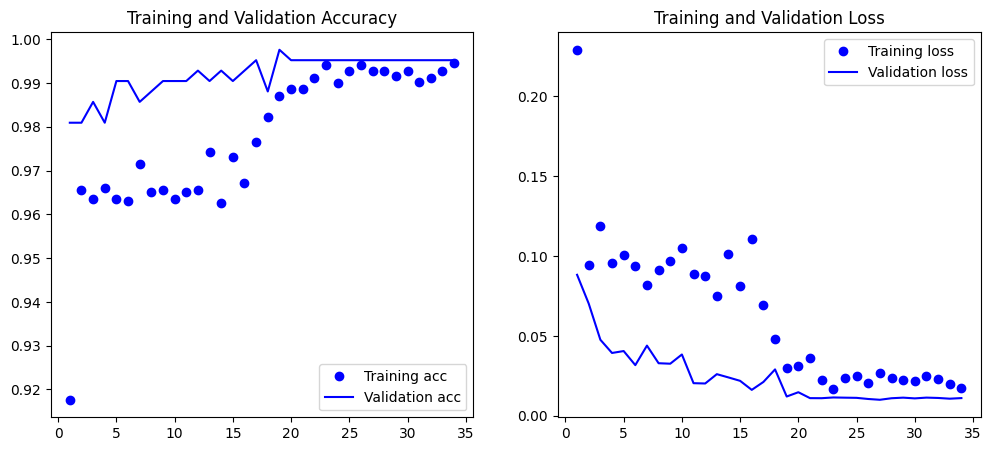

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history_list):
    # Combine history from Stage 1 and Stage 2
    acc = []
    val_acc = []
    loss = []
    val_loss = []

    for h in history_list:
        acc.extend(h.history['accuracy'])
        val_acc.extend(h.history['val_accuracy'])
        loss.extend(h.history['loss'])
        val_loss.extend(h.history['val_loss'])

    epochs = range(1, len(acc) + 1)

    # Plot Accuracy
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo', label='Training acc')
    plt.plot(epochs, val_acc, 'b', label='Validation acc')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    plt.show()

# Pass your history objects here
plot_history([history1, history2])

In [ ]:
# Save the model
model.save('brain_tumor_model.keras')
print("Model saved successfully!")

Model saved successfully!


In [ ]:
pip install tf-keras-vis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 5.5 MB/s eta 0:00:00


In [ ]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import random

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input


# ==========================================
# SETTINGS
# ==========================================
IMG_SIZE = 380
test_dir = "/content/extracted/archive/Testing"

class_names = ["No Tumor", "Tumor"]


# ==========================================
# LOAD MODEL
# ==========================================
model = load_model("best_model.keras")


# ==========================================
# FIND LAST CONVOLUTION LAYER AUTOMATICALLY
# ==========================================
last_conv_layer_name = None

for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

print("Last Conv Layer:", last_conv_layer_name)


# ==========================================
# GRAD-CAM FUNCTION
# ==========================================
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        model.inputs,
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)

    max_val = tf.reduce_max(heatmap)

    if max_val == 0:
        return heatmap.numpy()

    heatmap /= max_val

    return heatmap.numpy()


# ==========================================
# IMAGE PREPROCESSING
# ==========================================
def preprocess_image(img_path):

    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))

    img = image.img_to_array(img)

    img = np.expand_dims(img, axis=0)

    img = preprocess_input(img)

    return img


# ==========================================
# APPLY GRAD-CAM
# ==========================================
def apply_gradcam(img_path):

    img_array = preprocess_image(img_path)

    preds = model.predict(img_array)

    confidence = float(preds[0][0])

    class_idx = 1 if confidence > 0.5 else 0

    heatmap = make_gradcam_heatmap(
        img_array,
        model,
        last_conv_layer_name
    )

    # Load original image
    img = cv2.imread(img_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize heatmap
    heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))

    heatmap_uint8 = np.uint8(255 * heatmap)

    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(img, 0.6, heatmap_color, 0.4, 0)

    overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

    # ==========================================
    # PLOT RESULTS
    # ==========================================
    plt.figure(figsize=(14,4))

    plt.subplot(1,3,1)
    plt.title("Original")
    plt.imshow(img_rgb)
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Grad-CAM")
    plt.imshow(heatmap, cmap="jet")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Overlay")
    plt.imshow(overlay)
    plt.axis("off")

    plt.suptitle(
        f"Prediction: {class_names[class_idx]} | Confidence: {confidence:.3f}"
    )

    plt.show()


# ==========================================
# TEST ON RANDOM IMAGE
# ==========================================
some_class = random.choice(os.listdir(test_dir))

folder = os.path.join(test_dir, some_class)

example_img = os.path.join(folder, random.choice(os.listdir(folder)))

print("Running Grad-CAM on:", example_img)

apply_gradcam(example_img)

Last Conv Layer: None
Running Grad-CAM on: /content/extracted/archive/Testing/glioma/Te-gl_4.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


ValueError: Provide either a layer name or layer index at `get_layer`.